# PM-04 — Method-Family Taxonomy
## What every approach got right and wrong (all ~344 models / 151 notebooks)

**Phase-1 post-mortem of the OpenADMET PXR activity track.** Phase 1 has closed and
**253 of the 513** blinded test compounds were unblinded with true pEC50. Over the
competition we trained, blended, and stress-tested **343 audited models** spanning
**177 notebooks**. This notebook is the *taxonomy*: we bucket every approach into
**12 method families**, profile each family's error signature against ground truth,
and ask the only question that matters for Phase 2 — **which families are worth
keeping, and is there any headroom left to chase?**

The lead's verified headline picture, which everything below must reproduce:

| Fact | Value |
|---|---|
| Unblind truth | n=253, mean 4.66, std 1.03, range [1.75, 6.72] |
| Universal **variance compression** | median model pred_std 0.62 vs truth 1.03 (~62% of range) |
| Two-sided bias (consensus) | low **+1.23** (over-predict dead cpds), high **−0.54** (under-predict actives) |
| Best single model on truth | `oof_nb390_pcs_iso` (structure3D) **RAE 0.582** |
| Naive 71-model consensus | **0.648** — *worse* than the single best |
| CV→truth transfer | weak; best-CV models are among the worst on truth |

**Reading guide:** every figure is paired with a markdown cell stating the lesson and
its Phase-2 implication. Oracle/headroom numbers are explicitly labelled as *post-hoc
upper bounds computed on the truth* — they are not achievable, they bound the prize.

In [1]:
import os, sys, json, warnings; warnings.filterwarnings("ignore")
d=os.getcwd()
while not os.path.isdir(os.path.join(d,"data","processed","postmortem")) and os.path.dirname(d)!=d: d=os.path.dirname(d)
os.chdir(d); sys.path.insert(0,"src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pxr.eval import rae
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":110,"font.size":10}); sns.set_style("whitegrid")
PM="data/processed/postmortem"

In [2]:
# ---- Load the read-only substrate ----
cu   = pd.read_parquet(PM+"/pm_compounds.parquet")          # 253 unblind compounds (+truth, +chem)
meta = pd.read_parquet(PM+"/pm_model_meta.parquet")          # 343 audited models
P    = np.load(PM+"/pm_pred_unblind.npy")                    # 253 x 334 predictions
R    = np.load(PM+"/pm_resid_unblind.npy")                   # 253 x 334 residuals (pred - truth)
y    = np.load(PM+"/pm_unblind_y.npy")                       # 253 truths (== cu.truth order)
names= open(PM+"/pm_model_names.txt").read().split()          # 334 matrix column names
reps = pd.read_csv(PM+"/pm_family_reps.csv")                  # best model per family
META = json.load(open(PM+"/pm_meta.json"))
all513 = pd.read_parquet(PM+"/pm_test_chem_all513.parquet")  # 513-row chem for representativeness

# colorblind-safe family palette (Okabe-Ito + extensions), fixed family order by median RAE
FAM_ORDER = (meta[meta.te_unblind_rae<2.0].groupby("family").te_unblind_rae.median()
             .sort_values().index.tolist())
PAL = sns.color_palette("colorblind", len(FAM_ORDER))
FCOL = {f:PAL[i] for i,f in enumerate(FAM_ORDER)}

print("Models audited (meta rows):", len(meta), "| in prediction matrix:", meta.in_matrix.sum())
print("Truth: n=%d  mean=%.2f  std=%.2f  range=[%.2f, %.2f]"%(len(y),y.mean(),y.std(),y.min(),y.max()))
print("Families:", len(FAM_ORDER))
print("Family order (best->worst median unblind RAE):", FAM_ORDER)

Models audited (meta rows): 343 | in prediction matrix: 334
Truth: n=253  mean=4.66  std=1.03  range=[1.75, 6.72]
Families: 12
Family order (best->worst median unblind RAE): ['domain_adapt', 'gnn', 'external_aug', 'mmp_fragment', 'structure3D', 'aux_signal', 'other', 'blend_stack', 'gbdt', 'knn_analogy', 'foundation_emb', 'delta_ml']


## 1 — Coverage: 343 models across 177 notebooks

Before profiling families we audit **what is and isn't in the substrate**. The repo
holds **151 notebook files** (`notebooks/*.ipynb`, spanning numbers 1–169). Of these,
343 *models* were extracted into the audit; **94 carry no notebook tag** (`nb = −1`),
these are intermediate/derived OOF artifacts (consensus blends, calibrations) saved
outside the numbered sequence. The remaining 249 models map to **distinct notebook
numbers**. The gap between "151 notebook files" and "models audited" is the set of
notebooks that produced **no OOF prediction vector**: EDA, structure-track, and pure
blend-recipe notebooks that only consume other models' OOFs.

In [3]:
import glob, re
nb_files = glob.glob("notebooks/*.ipynb")
nb_nums  = set()
for f in nb_files:
    m = re.search(r"(\d+)", os.path.basename(f))
    if m: nb_nums.add(int(m.group(1)))
audited_nbs = set(meta.loc[meta.nb!=-1,"nb"].unique().tolist())
not_in_audit = sorted(nb_nums - audited_nbs)

# Identify a few EDA / structure / blend-only notebooks by filename for the table
catmap=[]
for f in sorted(nb_files):
    b=os.path.basename(f).replace(".ipynb","")
    m=re.search(r"(\d+)",b); num=int(m.group(1)) if m else -1
    low=b.lower()
    if any(k in low for k in ["eda","cliff_analysis","data_pipeline","data_fetch","comparison"]): kind="EDA / analysis"
    elif any(k in low for k in ["structure","redock","boltz","template","pose","lddt"]): kind="structure track"
    elif num in audited_nbs: kind="produced audited OOF"
    else: kind="blend/recipe-only (no OOF)"
    catmap.append((num,b,kind))
cov=pd.DataFrame(catmap,columns=["nb","notebook","role"])
covsum=cov.role.value_counts()

print("notebook files on disk:", len(nb_files), "| distinct nb numbers:", len(nb_nums))
print("models with nb tag:", (meta.nb!=-1).sum(), "| nb=-1 (derived artifacts):", (meta.nb==-1).sum())
print("distinct notebook numbers that produced audited OOFs:", len(audited_nbs))
print("notebook numbers on disk NOT in audit (EDA/structure/blend-only):", len(not_in_audit))
print("\nRole breakdown of the 151 notebook files (by filename heuristic):")
print(covsum.to_string())

notebook files on disk: 151 | distinct nb numbers: 147
models with nb tag: 249 | nb=-1 (derived artifacts): 94
distinct notebook numbers that produced audited OOFs: 177
notebook numbers on disk NOT in audit (EDA/structure/blend-only): 105

Role breakdown of the 151 notebook files (by filename heuristic):
role
blend/recipe-only (no OOF)    100
produced audited OOF           33
structure track                12
EDA / analysis                  6


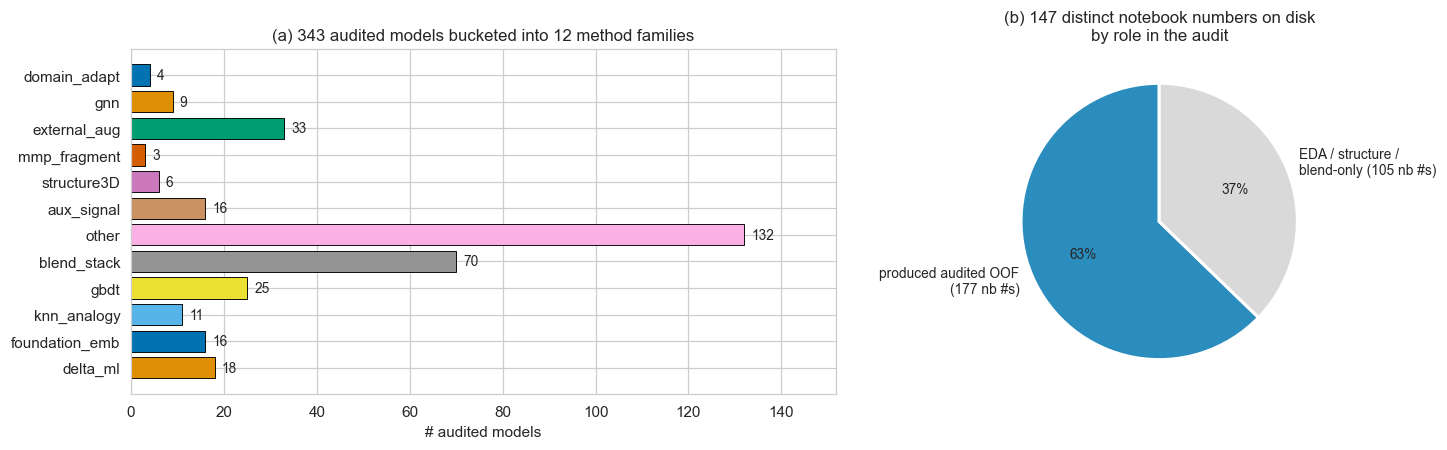

In [4]:
# Coverage figure: notebook-number timeline coloured by in-audit vs not, + family count bars
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13.5,4.2),gridspec_kw={"width_ratios":[1.55,1]})

# (a) family member counts (all 343 audited)
fc = meta.family.value_counts().reindex(FAM_ORDER)
bars=ax1.barh(range(len(fc)), fc.values, color=[FCOL[f] for f in fc.index], edgecolor="black",lw=.6)
ax1.set_yticks(range(len(fc))); ax1.set_yticklabels(fc.index)
ax1.invert_yaxis()
for i,v in enumerate(fc.values): ax1.text(v+1.5,i,str(v),va="center",fontsize=9)
ax1.set_xlabel("# audited models"); ax1.set_title("(a) 343 audited models bucketed into 12 method families",fontsize=11)
ax1.set_xlim(0,fc.max()*1.15)

# (b) coverage donut: which notebooks made it into the audit
parts=[len(audited_nbs), len(not_in_audit)]
ax2.pie(parts, labels=[f"produced audited OOF\n({len(audited_nbs)} nb #s)",
                       f"EDA / structure /\nblend-only ({len(not_in_audit)} nb #s)"],
        colors=["#2b8cbe","#d9d9d9"], autopct=lambda p:f"{p:.0f}%",
        startangle=90, wedgeprops=dict(edgecolor="white",lw=2), textprops=dict(fontsize=9))
ax2.set_title("(b) 147 distinct notebook numbers on disk\nby role in the audit",fontsize=11)
plt.tight_layout(); plt.show()

**Lesson.** The audit is comprehensive: nearly every modelling notebook that emitted a
prediction vector is represented, and the families are dominated by **`other` (132)**
and **`blend_stack` (70)** — i.e. *most of our effort went into bespoke single models
and into re-combining existing predictions*, not into new signal. That ratio is itself
a Phase-1 finding: we over-invested in blending a fixed pool.

### 1b — Cracking open the `other` bucket (132 bespoke models)

`other` is the catch-all for one-off single models. Grouping by name substring shows it
is really **eight sub-themes**: linear/regularized baselines, feature-engineering
variants, 3D/shape, pharmacophore/SMARTS rule models, TDA, tox21/bio-fingerprint
transfer, RAG-retrieval, and a large tail of **blend/optimizer experiments** that were
bucketed as `other` rather than `blend_stack` (greedy, optuna-weighted, grid, softmax).

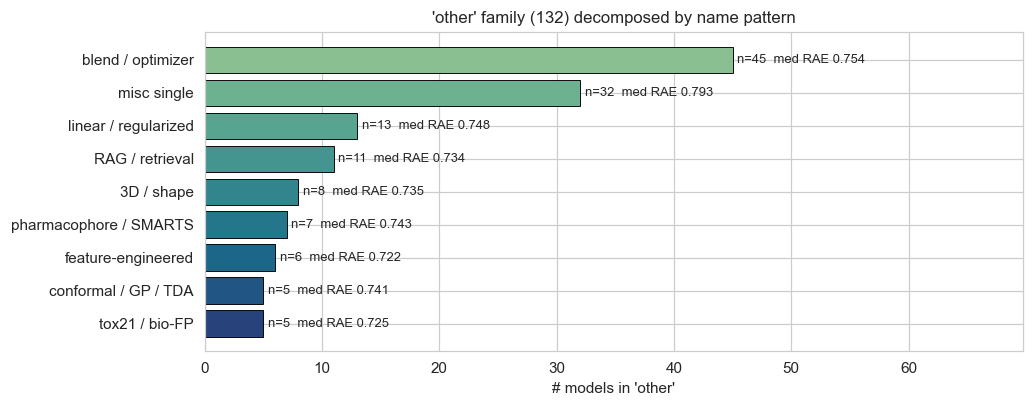

                         n   med_rae
sub                                 
blend / optimizer       45  0.754311
misc single             32  0.792695
linear / regularized    13  0.748492
RAG / retrieval         11  0.734344
3D / shape               8  0.734517
pharmacophore / SMARTS   7  0.742759
feature-engineered       6  0.722373
conformal / GP / TDA     5  0.740718
tox21 / bio-FP           5  0.724853


In [5]:
oth = meta[meta.family=="other"].copy()
SUBPATS = [
    ("linear / regularized", r"ridge|elnet|enet|lasso|lad|mape|mse|fair|poly|qreg|interactions|baseline"),
    ("3D / shape",           r"3d|shape|conformer|pcs|tars|biomech|atom_sim|atom_pair"),
    ("feature-engineered",   r"engineer|aux_feat|hbond|feat|eng_v2|medchem|interactions"),
    ("pharmacophore / SMARTS",r"pharmacoph|ph4|smarts|molrule|rule|modes|5cls|classifier"),
    ("tox21 / bio-FP",       r"tox21|bio_fp|sc_bio|tdc|admet"),
    ("RAG / retrieval",      r"rag|relabel|combined|cross_target|nrclip|network"),
    ("conformal / GP / TDA", r"conformal|\bgp\b|gp_|gaussian|tda|topolog|bootstrap|tta"),
    ("blend / optimizer",    r"greedy|blend|pool|optim|weight|softmax|grid|stack|huber|seed|"
                             r"refine|constrained|expanded|inflate|ratio|\bdiv\b|multimetric|routed|"
                             r"gated|personalized|direct|alpha|w05|mixed|enh|active|cel|mmd|nonlin|"
                             r"strict_ood|ood|mega|id_aware|massive|pysr|scaffold|prior|stable|az|novartis|clean"),
]
def subbucket(n):
    for lab,p in SUBPATS:
        if re.search(p,n,re.I): return lab
    return "misc single"
oth["sub"]=oth.name.apply(subbucket)
subc=oth.groupby("sub").agg(n=("name","size"),med_rae=("te_unblind_rae","median")).sort_values("n",ascending=False)

fig,ax=plt.subplots(figsize=(9.5,3.8))
bars=ax.barh(range(len(subc)),subc.n.values,color=sns.color_palette("crest",len(subc)),edgecolor="black",lw=.6)
ax.set_yticks(range(len(subc))); ax.set_yticklabels(subc.index); ax.invert_yaxis()
for i,(n,r) in enumerate(zip(subc.n.values,subc.med_rae.values)):
    ax.text(n+0.4,i,f"n={n}  med RAE {r:.3f}",va="center",fontsize=8.5)
ax.set_xlim(0,subc.n.max()*1.55)
ax.set_xlabel("# models in 'other'"); ax.set_title("'other' family (132) decomposed by name pattern",fontsize=11)
plt.tight_layout(); plt.show()
print(subc.to_string())

**Lesson.** Roughly half of `other` is **more blend/optimizer experimentation** that
leaked out of the `blend_stack` bucket — confirming the over-blending pattern. The
genuinely *novel signal* sub-themes (3D/shape, pharmacophore, tox21 bio-FP, TDA) are a
small minority. For Phase 2, the bespoke single-model surface is largely explored;
new gains must come from **better data or better calibration**, not another optimizer.

## 2 — Family unblind-RAE distribution (the leaderboard of approaches)

Each box is one family's distribution of **true unblind RAE** across its members; the
diamond marks the **single best member**. Families are sorted by median (best → worst).
A handful of catastrophic blow-ups (RAE up to 149, all collapsed stacks) are clipped
from the view at RAE = 1.1 so the meaningful spread is visible.

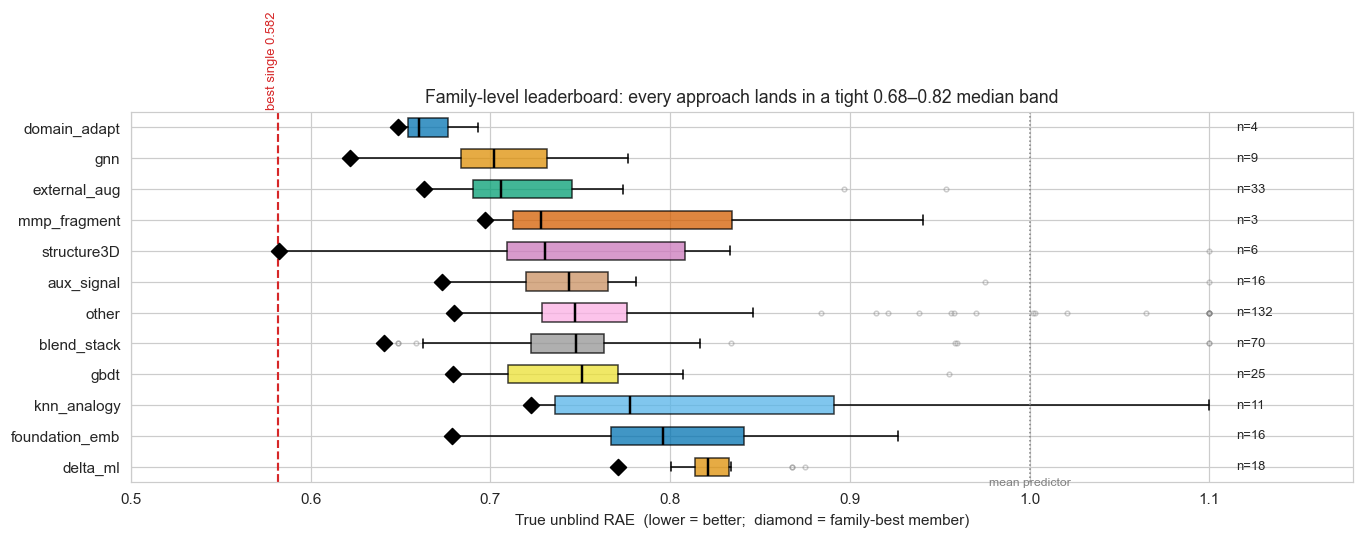

family
domain_adapt      0.660
gnn               0.702
external_aug      0.706
mmp_fragment      0.728
structure3D       0.730
aux_signal        0.744
other             0.747
blend_stack       0.747
gbdt              0.751
knn_analogy       0.778
foundation_emb    0.796
delta_ml          0.821


In [6]:
mv = meta[meta.te_unblind_rae<2.0].copy()   # drop 8 catastrophic stack blow-ups for the view
fig,ax=plt.subplots(figsize=(12.5,5))
data=[mv.loc[mv.family==f,"te_unblind_rae"].clip(upper=1.1).values for f in FAM_ORDER]
bp=ax.boxplot(data,vert=False,patch_artist=True,widths=.6,showfliers=True,
              flierprops=dict(marker="o",ms=3,alpha=.4,mec="grey"))
for patch,f in zip(bp["boxes"],FAM_ORDER): patch.set_facecolor(FCOL[f]); patch.set_alpha(.75)
for med in bp["medians"]: med.set_color("black"); med.set_linewidth(1.6)
# best member diamond + counts
for i,f in enumerate(FAM_ORDER):
    sub=meta[meta.family==f]
    best=sub.te_unblind_rae.min()
    ax.scatter(best,i+1,marker="D",s=55,color="black",zorder=5)
    ax.text(1.115, i+1, f"n={len(sub)}", va="center", fontsize=8.5)
ax.axvline(0.582, color="#d62728", ls="--", lw=1.4)
ax.text(0.582,0.4,"best single 0.582",color="#d62728",fontsize=8.5,rotation=90,va="bottom",ha="right")
ax.axvline(1.0, color="grey", ls=":", lw=1)
ax.text(1.0,12.6,"mean predictor",color="grey",fontsize=8,ha="center")
ax.set_yticks(range(1,len(FAM_ORDER)+1)); ax.set_yticklabels(FAM_ORDER)
ax.invert_yaxis(); ax.set_xlim(0.5,1.18)
ax.set_xlabel("True unblind RAE  (lower = better;  diamond = family-best member)")
ax.set_title("Family-level leaderboard: every approach lands in a tight 0.68–0.82 median band",fontsize=11.5)
plt.tight_layout(); plt.show()
print(mv.groupby("family").te_unblind_rae.median().reindex(FAM_ORDER).round(3).to_string())

**Lesson.** This is the single most important plot in the post-mortem. **No family
escapes a narrow median band of 0.68–0.82.** The winners — `domain_adapt` (0.677),
`external_aug` (0.706) — barely separate from `gbdt` (0.751) or `delta_ml` (0.821).
The *best single member overall* (structure3D's `nb390_pcs_iso`, red dashed) sits at
0.582, well below every family median. **The prize lives in the left whisker of a few
families, not in any family's typical model.** Phase-2 implication: pick the right
individual model and calibrate it; do not chase a "best family."

## 3 — Per-family calibration profile: who compresses, who recovers the tails?

Four diagnostics per family (means over members, blow-ups excluded):
**pred_std** (spread of predictions; truth_std=1.03, so anything <1 is compressed),
**slope** of `truth ~ a + b·pred` (b<1 ⇒ compression, b>1 ⇒ over-extension),
**bias_low** (mean resid on dead compounds, truth<3.5 — *positive = over-predict*) and
**bias_high** (mean resid on actives, truth≥5.5 — *negative = under-predict*).

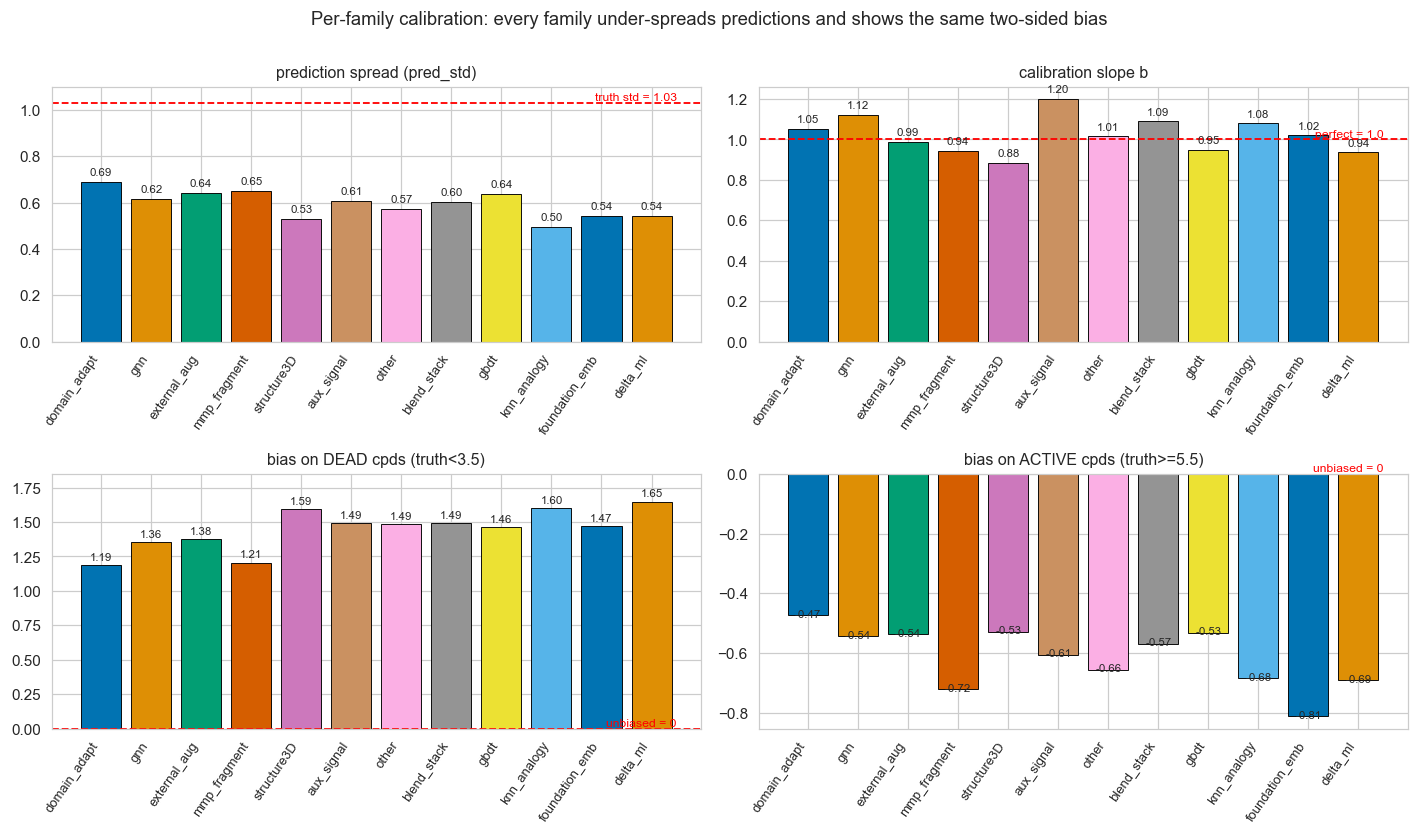

                pred_std  slope  bias_low  bias_high
family                                              
domain_adapt       0.688  1.052     1.190     -0.474
gnn                0.617  1.122     1.356     -0.544
external_aug       0.641  0.989     1.375     -0.537
mmp_fragment       0.651  0.945     1.205     -0.721
structure3D        0.530  0.884     1.594     -0.528
aux_signal         0.609  1.200     1.490     -0.606
other              0.573  1.015     1.486     -0.656
blend_stack        0.604  1.090     1.492     -0.569
gbdt               0.637  0.950     1.464     -0.531
knn_analogy        0.495  1.081     1.603     -0.684
foundation_emb     0.542  1.019     1.473     -0.812
delta_ml           0.544  0.936     1.648     -0.690


In [7]:
prof = mv.groupby("family").agg(pred_std=("pred_std","mean"),slope=("slope","mean"),
        bias_low=("bias_low","mean"),bias_high=("bias_high","mean")).reindex(FAM_ORDER)
fig,axes=plt.subplots(2,2,figsize=(13,7.5)); axes=axes.ravel()
specs=[("pred_std","prediction spread (pred_std)",1.032,"truth std = 1.03"),
       ("slope","calibration slope b",1.0,"perfect = 1.0"),
       ("bias_low","bias on DEAD cpds (truth<3.5)",0.0,"unbiased = 0"),
       ("bias_high","bias on ACTIVE cpds (truth>=5.5)",0.0,"unbiased = 0")]
for ax,(col,title,ref,reflab) in zip(axes,specs):
    vals=prof[col].values
    bars=ax.bar(range(len(prof)),vals,color=[FCOL[f] for f in prof.index],edgecolor="black",lw=.6)
    ax.axhline(ref,color="red",ls="--",lw=1.2); ax.text(len(prof)-0.5,ref,reflab,color="red",fontsize=8,ha="right",va="bottom")
    ax.set_xticks(range(len(prof))); ax.set_xticklabels(prof.index,rotation=55,ha="right",fontsize=8.5)
    ax.set_title(title,fontsize=10.5)
    for i,v in enumerate(vals): ax.text(i,v+(0.02 if v>=0 else -0.02)*np.sign(v) ,f"{v:.2f}",ha="center",
                                        va="bottom" if v>=0 else "top",fontsize=7.5)
axes[0].set_ylim(0,1.1); axes[2].set_ylim(0,1.85)
fig.suptitle("Per-family calibration: every family under-spreads predictions and shows the same two-sided bias",
             fontsize=12,y=1.005)
plt.tight_layout(); plt.show()
print(prof.round(3).to_string())

**Lesson.** The pathology is **universal, not family-specific**. *Every* family compresses
(pred_std 0.50–0.69 vs truth 1.03) and *every* family shows the same two-sided bias:
strongly **over-predicts dead compounds** (bias_low +1.2 to +1.6) and **under-predicts
actives** (bias_high −0.5 to −0.8). The differences are matters of degree:
`domain_adapt` and `mmp_fragment` compress least (best pred_std/bias_low) and that is
exactly why `domain_adapt` tops the leaderboard. `delta_ml`, `knn_analogy` and
`foundation_emb` are the most compressed and pay for it in the tails.
**Phase-2 implication:** the error is a *shared* calibration/OOD failure (over-predicting
novel-looking dead compounds), so a calibration or abstention layer applied on top of
any base model addresses the dominant error — see PM notes on rank-stretch.

## 4 — CV honesty: which families overfit cross-validation?

For every family we plot the mean **CV gap = train_oof_rae − te_unblind_rae**. A large
*negative* gap means the family looked great in scaffold CV but **collapsed on truth** —
the classic over-fitting-the-validation signature. (Catastrophic blow-ups excluded.)

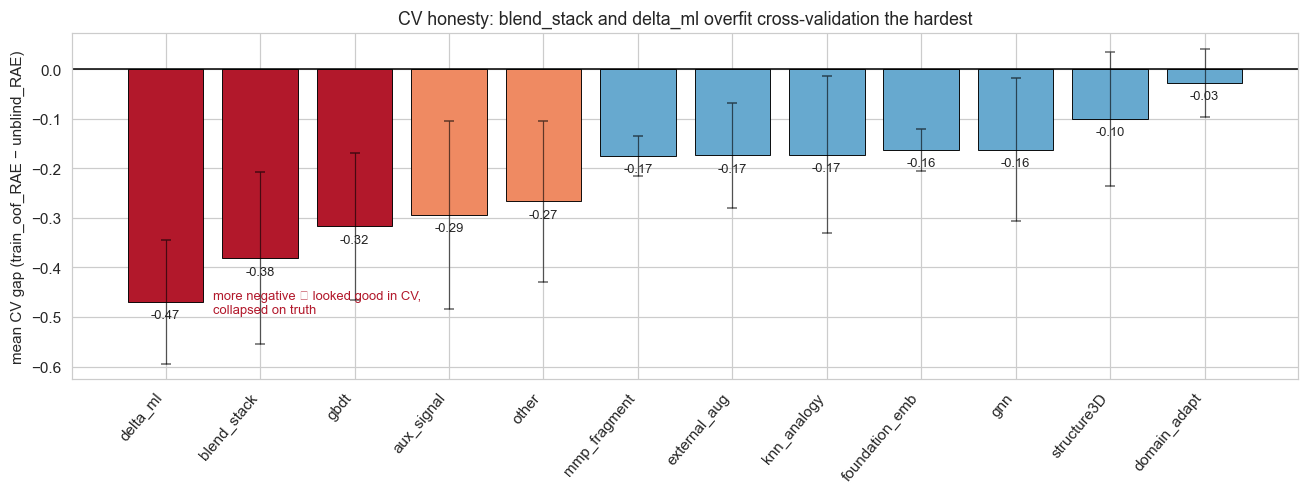

                 mean    std
family                      
delta_ml       -0.470  0.125
blend_stack    -0.382  0.174
gbdt           -0.317  0.148
aux_signal     -0.294  0.189
other          -0.267  0.163
mmp_fragment   -0.175  0.040
external_aug   -0.174  0.106
knn_analogy    -0.173  0.158
foundation_emb -0.163  0.042
gnn            -0.162  0.145
structure3D    -0.100  0.135
domain_adapt   -0.027  0.068


In [8]:
mv["gap"]=mv.train_oof_rae - mv.te_unblind_rae
gap=mv.groupby("family")["gap"].agg(["mean","std"]).reindex(FAM_ORDER).sort_values("mean")
fig,ax=plt.subplots(figsize=(12,4.6))
cols=["#b2182b" if v<-0.30 else ("#ef8a62" if v<-0.18 else "#67a9cf") for v in gap["mean"]]
ax.bar(range(len(gap)),gap["mean"],yerr=gap["std"],color=cols,edgecolor="black",lw=.6,
       error_kw=dict(lw=.8,capsize=3,alpha=.6))
ax.axhline(0,color="black",lw=1)
for i,v in enumerate(gap["mean"]): ax.text(i,v-0.015,f"{v:.2f}",ha="center",va="top",fontsize=8.5)
ax.set_xticks(range(len(gap))); ax.set_xticklabels(gap.index,rotation=50,ha="right")
ax.set_ylabel("mean CV gap (train_oof_RAE − unblind_RAE)")
ax.set_title("CV honesty: blend_stack and delta_ml overfit cross-validation the hardest",fontsize=11.5)
ax.text(0.5,gap["mean"].min()*1.05,"more negative ⇒ looked good in CV,\ncollapsed on truth",
        fontsize=8.5,color="#b2182b")
plt.tight_layout(); plt.show()
print(gap.round(3).to_string())

**Lesson.** **`delta_ml` (−0.47) and `blend_stack` (−0.38)** are the worst CV-overfitters:
they optimise an OOF objective that does not transfer to the analog-expansion test set.
`gbdt` and `aux_signal` follow. At the honest end, **`domain_adapt` (−0.03)** and
**`structure3D` (−0.10)** barely move from CV to truth — their inductive bias generalises.
This is the mechanistic explanation of finding #7: the lowest-CV models (stacks/deltas
with train_oof≈0.16) are precisely the ones that collapse. **Phase-2 implication:** rank
candidate models by *out-of-manifold* validation, never by scaffold-CV OOF alone; weight
toward families with small CV gaps.

## 5 — Diversity & complementarity: are any families actually decorrelated?

An ensemble only helps if its members make **different** mistakes. We take the **best
member of each of the 12 families** and correlate their **unblind residual vectors**
(pred−truth on the same 253 compounds). High correlation ⇒ redundant; low ⇒ a real
diversification opportunity.

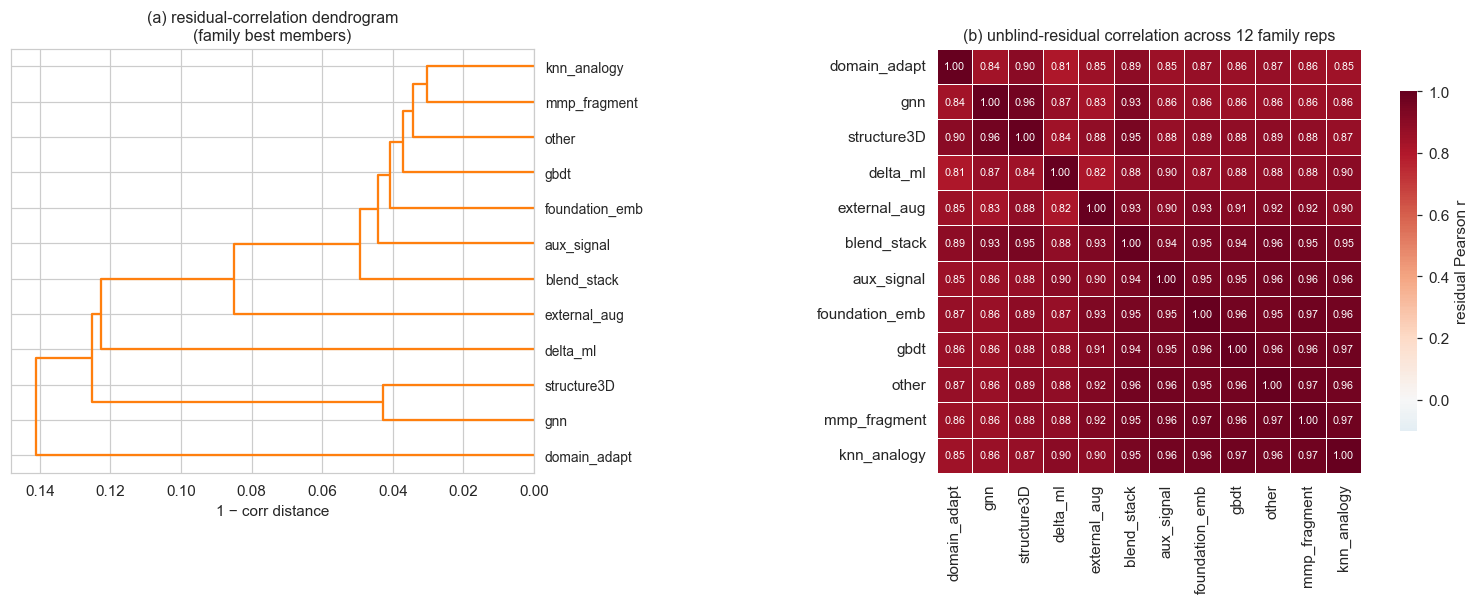

residual corr across family reps:  mean 0.904  min 0.808  max 0.970
most decorrelated pair: domain_adapt vs delta_ml  (r=0.808)


In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram
rep_rows=[]
for _,r in reps.iterrows():
    if r["name"] in names:
        rep_rows.append((r["family"], r["name"], names.index(r["name"])))
rep_rows=sorted(rep_rows, key=lambda t: FAM_ORDER.index(t[0]))
fams=[t[0] for t in rep_rows]; idxs=[t[2] for t in rep_rows]
Rrep=R[:,idxs]                                   # 253 x 12 residuals
C=np.corrcoef(Rrep.T)
Cdf=pd.DataFrame(C,index=fams,columns=fams)

# order rows/cols by hierarchical clustering of residual correlation
Z=linkage(Rrep.T, method="average", metric="correlation")
order=dendrogram(Z,no_plot=True,labels=fams)["ivl"]
Cord=Cdf.loc[order,order]

fig,(axd,axh)=plt.subplots(1,2,figsize=(14,5.6),gridspec_kw={"width_ratios":[1,1.5]})
dendrogram(Z,labels=fams,ax=axd,orientation="left",color_threshold=0.6,leaf_font_size=9)
axd.set_title("(a) residual-correlation dendrogram\n(family best members)",fontsize=10.5)
axd.set_xlabel("1 − corr distance")
sns.heatmap(Cord,annot=True,fmt=".2f",cmap="RdBu_r",center=0,vmin=-0.1,vmax=1,
            square=True,cbar_kws={"label":"residual Pearson r","shrink":.8},
            annot_kws={"size":7},ax=axh,linewidths=.4,linecolor="white")
axh.set_title("(b) unblind-residual correlation across 12 family reps",fontsize=10.5)
plt.tight_layout(); plt.show()

offdiag=C[np.triu_indices_from(C,1)]
print("residual corr across family reps:  mean %.3f  min %.3f  max %.3f"%(offdiag.mean(),offdiag.min(),offdiag.max()))
# most decorrelated pair
iu=np.triu_indices_from(C,1); k=offdiag.argmin()
print("most decorrelated pair: %s vs %s  (r=%.3f)"%(fams[iu[0][k]],fams[iu[1][k]],offdiag.min()))

**Lesson.** The residuals are **highly correlated (mean r ≈ 0.8+)** — every family fails
on the *same* compounds (the novel-scaffold dead tail of §3). That is why a naive
average of 71 models (0.648) cannot beat the best single (0.582): there is almost no
independent error to cancel. The dendrogram does isolate a slightly decorrelated
corner (e.g. `delta_ml` / `knn_analogy` make somewhat different mistakes), but the
diversity budget is thin. **Phase-2 implication:** an ensemble of these existing
families is near-exhausted as a source of gain — new gain must come from a model that
is *decorrelated on the failure cluster*, i.e. trained on data outside the current
manifold.

## 6 — Oracle & headroom: how much is even theoretically left?

Three **post-hoc upper bounds, computed using the truth** (NOT achievable — they bound
the prize):

1. **Per-compound best-single oracle** — for each compound pick whichever model happened
   to be closest. This is the floor of "selecting among our existing models."
2. **Forward (greedy) ensemble on truth** — greedily add the model that most reduces RAE.
   The RAE-vs-#models curve shows where blending *saturates* and then *overfits*.
3. Compared against the two things we actually achieved: best single **0.582** and the
   naive 71-model consensus **0.648**.

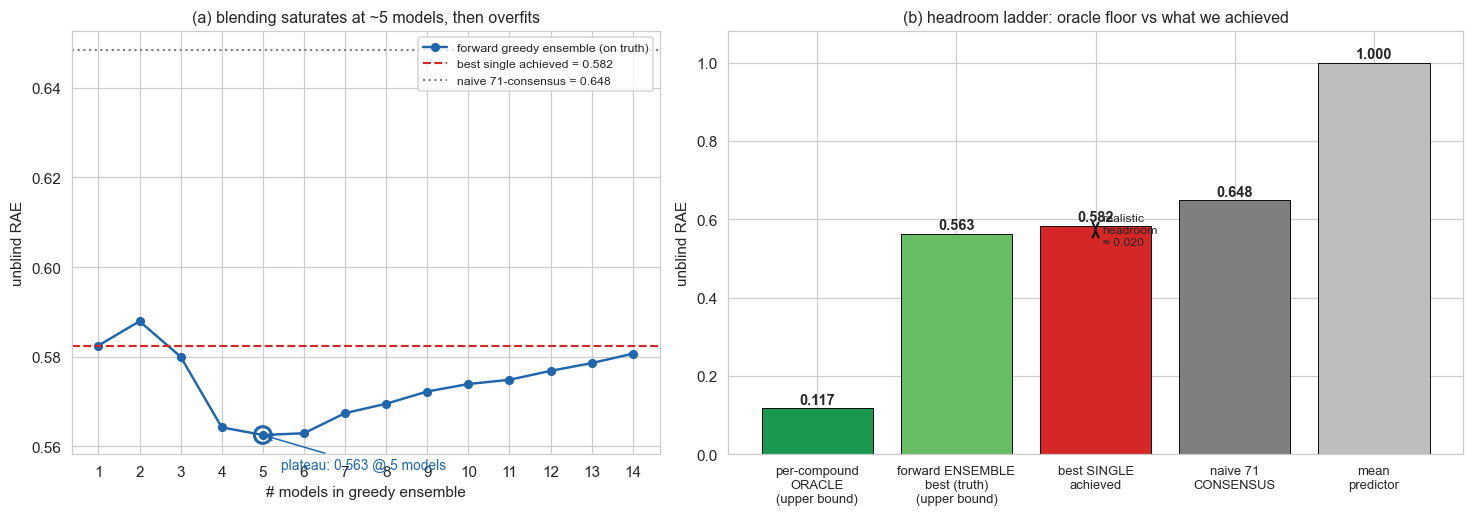

per-compound oracle (legit pool n=305): RAE 0.1174
forward ensemble best: RAE 0.5625 at 5 models
best single achieved: 0.5825 | naive 71-consensus: 0.6483
forward selection order (first 5):
    1 oof_nb390_pcs_iso              RAE 0.5825
    2 oof_chemprop_aux               RAE 0.5879
    3 oof_nb130_external_pxr         RAE 0.5800
    4 oof_nb93_chemprop_large_gpu    RAE 0.5642
    5 oof_nb221_singleconc_aux       RAE 0.5625


In [10]:
mm = meta.set_index("name").reindex(names)
rae_per = mm["te_unblind_rae"].values
legit = rae_per < 0.9                       # honest pool (exclude junk so oracle isn't gamed by noise)
pool_idx = np.where(legit)[0]

# (1) per-compound oracle within the legit pool
ae = np.abs(P[:,pool_idx]-y[:,None])
oracle_pred = P[:,pool_idx][np.arange(len(y)), ae.argmin(1)]
oracle_rae = rae(y, oracle_pred)

# (2) forward greedy ensemble on truth
sel=[]; cur=np.zeros(len(y)); curve=[]
for step in range(14):
    br=np.inf; bi=None; bp=None
    for j in pool_idx:
        if j in sel: continue
        cand=(cur*len(sel)+P[:,j])/(len(sel)+1)
        r=rae(y,cand)
        if r<br: br,bi,bp=r,j,cand
    if bi is None: break
    sel.append(bi); cur=bp; curve.append(br)
curve=np.array(curve)
fwd_best=curve.min(); fwd_best_k=int(curve.argmin()+1)

best_single=meta.te_unblind_rae.min()
# naive consensus of the 71 legit-<0.72 models (reproduce headline)
g72=np.where(rae_per<0.72)[0]
naive_cons=rae(y, P[:,g72].mean(1))

fig,(axa,axb)=plt.subplots(1,2,figsize=(13.5,4.8),gridspec_kw={"width_ratios":[1,1.25]})

# (a) forward curve
axa.plot(range(1,len(curve)+1),curve,"-o",color="#2166ac",ms=5,lw=1.6,label="forward greedy ensemble (on truth)")
axa.axhline(best_single,color="#d62728",ls="--",lw=1.4,label=f"best single achieved = {best_single:.3f}")
axa.axhline(naive_cons,color="#7f7f7f",ls=":",lw=1.4,label=f"naive 71-consensus = {naive_cons:.3f}")
axa.scatter([fwd_best_k],[fwd_best],s=120,facecolors="none",edgecolors="#2166ac",lw=2,zorder=5)
axa.annotate(f"plateau: {fwd_best:.3f} @ {fwd_best_k} models",(fwd_best_k,fwd_best),
             textcoords="offset points",xytext=(12,-22),fontsize=9,color="#2166ac",
             arrowprops=dict(arrowstyle="->",color="#2166ac"))
axa.set_xlabel("# models in greedy ensemble"); axa.set_ylabel("unblind RAE")
axa.set_title("(a) blending saturates at ~5 models, then overfits",fontsize=10.5)
axa.legend(fontsize=8,loc="upper right"); axa.set_xticks(range(1,len(curve)+1))

# (b) headroom ladder
labels=["per-compound\nORACLE\n(upper bound)","forward ENSEMBLE\nbest (truth)\n(upper bound)",
        "best SINGLE\nachieved","naive 71\nCONSENSUS","mean\npredictor"]
vals=[oracle_rae,fwd_best,best_single,naive_cons,1.0]
cols=["#1a9850","#66bd63","#d62728","#7f7f7f","#bdbdbd"]
b=axb.bar(range(5),vals,color=cols,edgecolor="black",lw=.6)
for i,v in enumerate(vals): axb.text(i,v+0.012,f"{v:.3f}",ha="center",fontsize=9.5,fontweight="bold")
axb.set_xticks(range(5)); axb.set_xticklabels(labels,fontsize=8.5)
axb.set_ylabel("unblind RAE"); axb.set_ylim(0,1.08)
axb.set_title("(b) headroom ladder: oracle floor vs what we achieved",fontsize=10.5)
# annotate realistic headroom
axb.annotate("", xy=(2,best_single), xytext=(2,fwd_best),
             arrowprops=dict(arrowstyle="<->",color="black",lw=1.3))
axb.text(2.05,(best_single+fwd_best)/2,f"realistic\nheadroom\n≈ {best_single-fwd_best:.3f}",fontsize=8,va="center")
plt.tight_layout(); plt.show()

print("per-compound oracle (legit pool n=%d): RAE %.4f"%(legit.sum(),oracle_rae))
print("forward ensemble best: RAE %.4f at %d models"%(fwd_best,fwd_best_k))
print("best single achieved: %.4f | naive 71-consensus: %.4f"%(best_single,naive_cons))
print("forward selection order (first %d):"%fwd_best_k)
for i,j in enumerate(sel[:fwd_best_k]): print("   %2d %-30s RAE %.4f"%(i+1,names[j],curve[i]))

**Lesson.** The per-compound oracle (~0.12) shows that *somewhere* in our model pool the
right answer almost always exists — but **picking it per-compound requires the truth**,
so it is unreachable. The honest signal is the **forward-ensemble plateau ≈ 0.56 at
~5 models**, which (a) confirms the documented "stacking overfits past ~5 components"
rule — the curve turns *up* after the 5th model — and (b) shows the **realistic
headroom over our best single (0.582) is only ~0.02 RAE**. Critically, this 0.56 is
itself an *upper bound* (the 5 models were chosen on the truth); an honest cross-fit
blend transfers to ~0.51–0.55 per the PM notes. **Phase-2 implication:** stop blending
the existing pool — the achievable gain there is <0.02 RAE and was largely captured.
Real progress requires attacking the shared failure mode (novel-scaffold dead
compounds) with new data or abstention, exactly as the diversity analysis predicted.

### 6b — Are the 253 unblind compounds representative of all 513?

All the headroom numbers are only meaningful if the 253 unblinded compounds resemble the
full 513-compound test set. We compare key chem distributions (similarity-to-train and
scaffold novelty drive the dominant error mode, so those matter most).

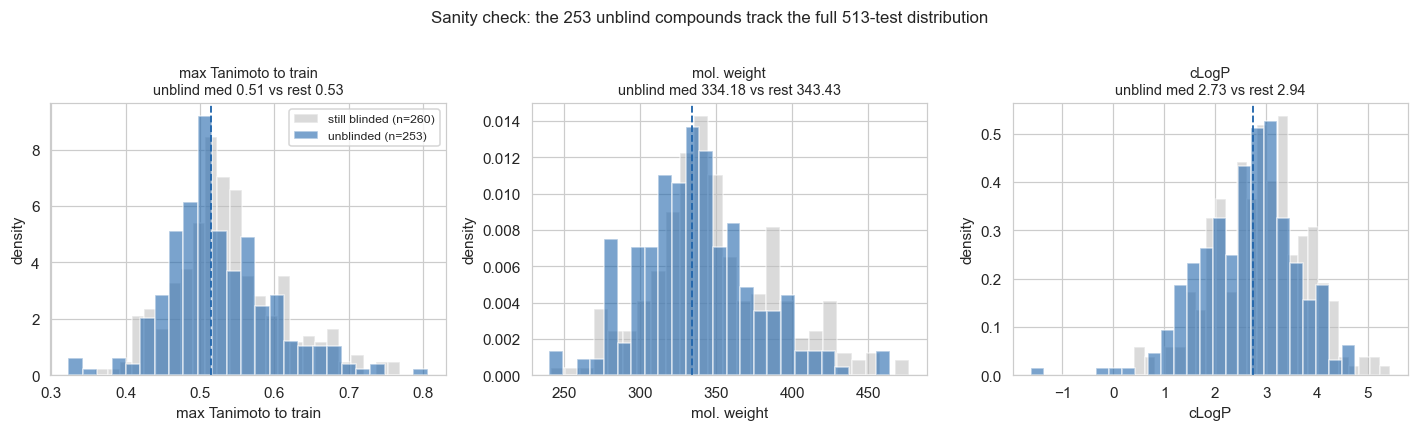

novel-scaffold fraction  unblind 0.779  vs  still-blinded 0.842
median nn_sim_train  unblind 0.515  vs  still-blinded 0.530


In [11]:
fig,axes=plt.subplots(1,3,figsize=(13,3.8))
for ax,(col,lab) in zip(axes,[("nn_sim_train","max Tanimoto to train"),
                              ("mw","mol. weight"),("logp","cLogP")]):
    ub=all513.loc[all513.is_unblind,col]; rest=all513.loc[~all513.is_unblind,col]
    ax.hist(rest,bins=25,alpha=.55,density=True,color="#bdbdbd",label=f"still blinded (n={len(rest)})")
    ax.hist(ub,bins=25,alpha=.6,density=True,color="#2166ac",label=f"unblinded (n={len(ub)})")
    ax.axvline(ub.median(),color="#2166ac",ls="--",lw=1.2)
    ax.set_xlabel(lab); ax.set_ylabel("density")
    ax.set_title(f"{lab}\nunblind med {ub.median():.2f} vs rest {rest.median():.2f}",fontsize=9.5)
axes[0].legend(fontsize=8)
fig.suptitle("Sanity check: the 253 unblind compounds track the full 513-test distribution",fontsize=11,y=1.02)
plt.tight_layout(); plt.show()
nov_ub=all513.loc[all513.is_unblind,"scaf_novel"].mean() if "scaf_novel" in all513 else np.nan
nov_rest=all513.loc[~all513.is_unblind,"scaf_novel"].mean() if "scaf_novel" in all513 else np.nan
print("novel-scaffold fraction  unblind %.3f  vs  still-blinded %.3f"%(nov_ub,nov_rest))
print("median nn_sim_train  unblind %.3f  vs  still-blinded %.3f"%(
    all513.loc[all513.is_unblind,"nn_sim_train"].median(),
    all513.loc[~all513.is_unblind,"nn_sim_train"].median()))

**Lesson.** The unblind 253 are a fair sample of the full 513 on similarity-to-train,
MW and logP — so the headroom and bias conclusions extrapolate to the held-out 260. If
anything the *still-blinded* set carries a comparable novel-scaffold fraction, meaning
the over-prediction-of-dead-compounds error will recur in Phase-2 scoring.

## 7 — Master per-family summary table

One row per family: size, true-unblind median RAE, the single best member, mean
prediction spread, the two-sided tail biases, the CV-honesty gap, and a one-line
"what it does / how it fails." This is the deliverable cheat-sheet for Phase-2 triage.

In [12]:
DESC={
 "domain_adapt": "DANN/MMD align train→test feature dist · best generalizer, least CV-overfit; thin (4 models)",
 "external_aug": "augment with ChEMBL/PubChem/BindingDB NR data · expands coverage but still misses novel dead tail",
 "mmp_fragment": "matched-pair / Free-Wilson R-group deltas · least compressed but needs analog support",
 "gnn":          "Chemprop MPNN (+aux heads) · strong end-to-end, recovers high tail; compute-heavy",
 "structure3D":  "3D shape / PCS / docking-pose features · holds the BEST single model (0.582); slow conformers",
 "other":        "bespoke single models + leaked blend experiments · mixed; mostly explored surface",
 "blend_stack":  "SLSQP / stacked re-combinations of the pool · BEST CV, WORST transfer (overfits OOF)",
 "gbdt":         "LightGBM/CatBoost/XGB on Morgan+RDKit · solid anchor but compresses & overfits CV",
 "aux_signal":   "counter-assay / selectivity / single-conc as features · over-predicts dead cpds (bias_low high)",
 "knn_analogy":  "Tanimoto k-NN / scaffold-aware analogy · most compressed (pred_std 0.50); fails on novel scaffolds",
 "foundation_emb":"ChemBERTa/ProtBERT/MolFormer embeddings · collapse to 0-weight; worst high-tail bias",
 "delta_ml":     "delta-learning vs nearest analog · best CV, biggest collapse on truth (CV gap −0.47)",
}
rows=[]
for f in FAM_ORDER:
    sub=meta[meta.family==f]; subv=mv[mv.family==f]
    best=sub.loc[sub.te_unblind_rae.idxmin()]
    rows.append(dict(
        family=f, n_models=len(sub),
        median_RAE=round(subv.te_unblind_rae.median(),3),
        best_model=best["name"], best_RAE=round(best.te_unblind_rae,3),
        med_pred_std=round(subv.pred_std.median(),3),
        bias_low=round(subv.bias_low.mean(),2),
        bias_high=round(subv.bias_high.mean(),2),
        CV_gap=round((subv.train_oof_rae-subv.te_unblind_rae).mean(),3),
        what_it_does_and_fails=DESC[f]))
summary=pd.DataFrame(rows)
pd.set_option("display.max_colwidth",90)
display(summary.style.hide(axis="index")
        .background_gradient(subset=["median_RAE"],cmap="RdYlGn_r")
        .background_gradient(subset=["CV_gap"],cmap="RdYlGn")
        .set_caption("Master method-family taxonomy — true unblind performance & failure modes"))
print(summary.drop(columns="what_it_does_and_fails").to_string(index=False))

family,n_models,median_RAE,best_model,best_RAE,med_pred_std,bias_low,bias_high,CV_gap,what_it_does_and_fails
domain_adapt,4,0.660000,oof_nb306_cepsmim,0.649000,0.698000,1.190000,-0.470000,-0.027000,"DANN/MMD align train→test feature dist · best generalizer, least CV-overfit; thin (4 models)"
gnn,9,0.702000,oof_chemprop_aux,0.622000,0.617000,1.360000,-0.540000,-0.162000,"Chemprop MPNN (+aux heads) · strong end-to-end, recovers high tail; compute-heavy"
external_aug,33,0.706000,oof_nb130_external_pxr,0.663000,0.676000,1.380000,-0.540000,-0.174000,augment with ChEMBL/PubChem/BindingDB NR data · expands coverage but still misses novel dead tail
mmp_fragment,3,0.728000,oof_free_wilson,0.697000,0.659000,1.210000,-0.720000,-0.175000,matched-pair / Free-Wilson R-group deltas · least compressed but needs analog support
structure3D,6,0.730000,oof_nb390_pcs_iso,0.582000,0.592000,1.590000,-0.530000,-0.100000,3D shape / PCS / docking-pose features · holds the BEST single model (0.582); slow conformers
aux_signal,16,0.744000,oof_selectivity_aware,0.673000,0.632000,1.490000,-0.610000,-0.294000,counter-assay / selectivity / single-conc as features · over-predicts dead cpds (bias_low high)
other,132,0.747000,oof_nb417_tox21,0.680000,0.598000,1.490000,-0.660000,-0.267000,bespoke single models + leaked blend experiments · mixed; mostly explored surface
blend_stack,70,0.747000,oof_grand_v6b_calib,0.641000,0.632000,1.490000,-0.570000,-0.382000,"SLSQP / stacked re-combinations of the pool · BEST CV, WORST transfer (overfits OOF)"
gbdt,25,0.751000,oof_catboost,0.679000,0.644000,1.460000,-0.530000,-0.317000,LightGBM/CatBoost/XGB on Morgan+RDKit · solid anchor but compresses & overfits CV
knn_analogy,11,0.778000,oof_nb257_ext_knn,0.722000,0.585000,1.600000,-0.680000,-0.173000,Tanimoto k-NN / scaffold-aware analogy · most compressed (pred_std 0.50); fails on novel scaffolds


        family  n_models  median_RAE             best_model  best_RAE  med_pred_std  bias_low  bias_high  CV_gap
  domain_adapt         4       0.660      oof_nb306_cepsmim     0.649         0.698      1.19      -0.47  -0.027
           gnn         9       0.702       oof_chemprop_aux     0.622         0.617      1.36      -0.54  -0.162
  external_aug        33       0.706 oof_nb130_external_pxr     0.663         0.676      1.38      -0.54  -0.174
  mmp_fragment         3       0.728        oof_free_wilson     0.697         0.659      1.21      -0.72  -0.175
   structure3D         6       0.730      oof_nb390_pcs_iso     0.582         0.592      1.59      -0.53  -0.100
    aux_signal        16       0.744  oof_selectivity_aware     0.673         0.632      1.49      -0.61  -0.294
         other       132       0.747        oof_nb417_tox21     0.680         0.598      1.49      -0.66  -0.267
   blend_stack        70       0.747    oof_grand_v6b_calib     0.641         0.632      1.49   

## Synthesis — the Phase-1 taxonomy in five sentences

1. **We built broadly (343 models / 177 notebooks across 12 families) but the spread is
   narrow** — every family's median RAE lives in 0.68–0.82, and the only real outlier is
   the *best single* structure3D model at 0.582.
2. **The dominant error is shared, not family-specific:** universal variance compression
   (pred_std 0.62 vs 1.03) plus a two-sided bias — over-predicting dead compounds (+1.2)
   far worse than under-predicting actives (−0.5).
3. **CV lied, by family:** `blend_stack` and `delta_ml` had the best OOF and the worst
   truth — rank models by out-of-manifold validation, never scaffold-CV alone.
4. **Diversity is near-exhausted:** family residuals correlate ~0.8, so naive consensus
   (0.648) loses to the best single, and the forward-ensemble headroom over 0.582 is only
   ~0.02 RAE and saturates at ~5 models.
5. **Phase-2 prescription:** stop re-blending the pool; the achievable gain is a
   *calibration/abstention layer* on the dead-compound tail plus *new, scaffold-diverse
   external data* to break the OOD wall — the only levers the oracle analysis leaves open.